In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")
print(df.head())

Mounted at /content/gdrive
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      1

In [4]:
print("Dữ liệu đã được tải thành công!")
print(f"Kích thước bộ dữ liệu: {df.shape[0]:,} dòng và {df.shape[1]} cột.")

Dữ liệu đã được tải thành công!
Kích thước bộ dữ liệu: 253,680 dòng và 22 cột.


In [5]:
null_counts = df.isnull().sum().sum()
print(f"Tổng số giá trị khuyết thiếu (Null): {null_counts}")

print("\n--- SỐ LƯỢNG GIÁ TRỊ PHÂN BIỆT (CARDINALITY) ---")
unique_counts = df.nunique().sort_values()
cardinality_df = pd.DataFrame({'Thuộc tính': unique_counts.index, 'Số giá trị Unique': unique_counts.values})
display(cardinality_df.T)

Tổng số giá trị khuyết thiếu (Null): 0

--- SỐ LƯỢNG GIÁ TRỊ PHÂN BIỆT (CARDINALITY) ---


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
Thuộc tính,Diabetes_binary,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,AnyHealthcare,Fruits,...,NoDocbcCost,DiffWalk,Sex,GenHlth,Education,Income,Age,MentHlth,PhysHlth,BMI
Số giá trị Unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,5,6,8,13,31,31,84


/tmp/ipykernel_19589/2565196357.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Diabetes_binary', data=df, palette=['#1f77b4', '#ff7f0e'])


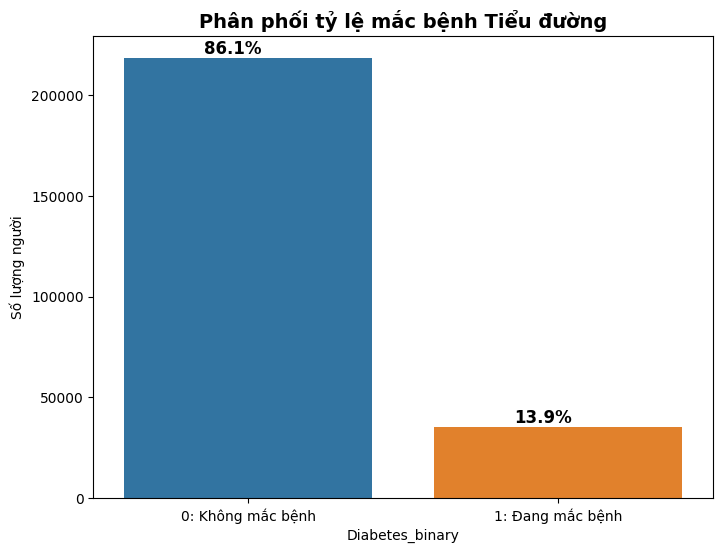

In [6]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Diabetes_binary', data=df, palette=['#1f77b4', '#ff7f0e'])

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Phân phối tỷ lệ mắc bệnh Tiểu đường', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['0: Không mắc bệnh', '1: Đang mắc bệnh'])
plt.ylabel('Số lượng người')
plt.show()

/tmp/ipykernel_19589/830732454.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.head(10).values, y=target_corr.head(10).index, palette='magma')


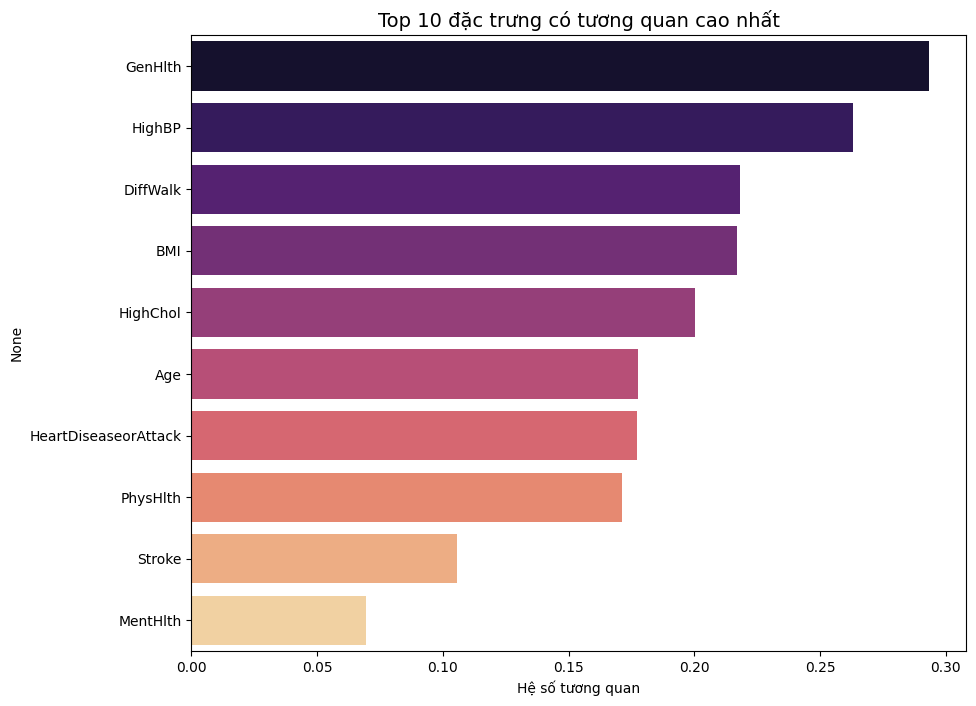

In [7]:
plt.figure(figsize=(10, 8))

corr_matrix = df.corr()
target_corr = corr_matrix['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)

sns.barplot(x=target_corr.head(10).values, y=target_corr.head(10).index, palette='magma')
plt.title('Top 10 đặc trưng có tương quan cao nhất', fontsize=14)
plt.xlabel('Hệ số tương quan')
plt.show()

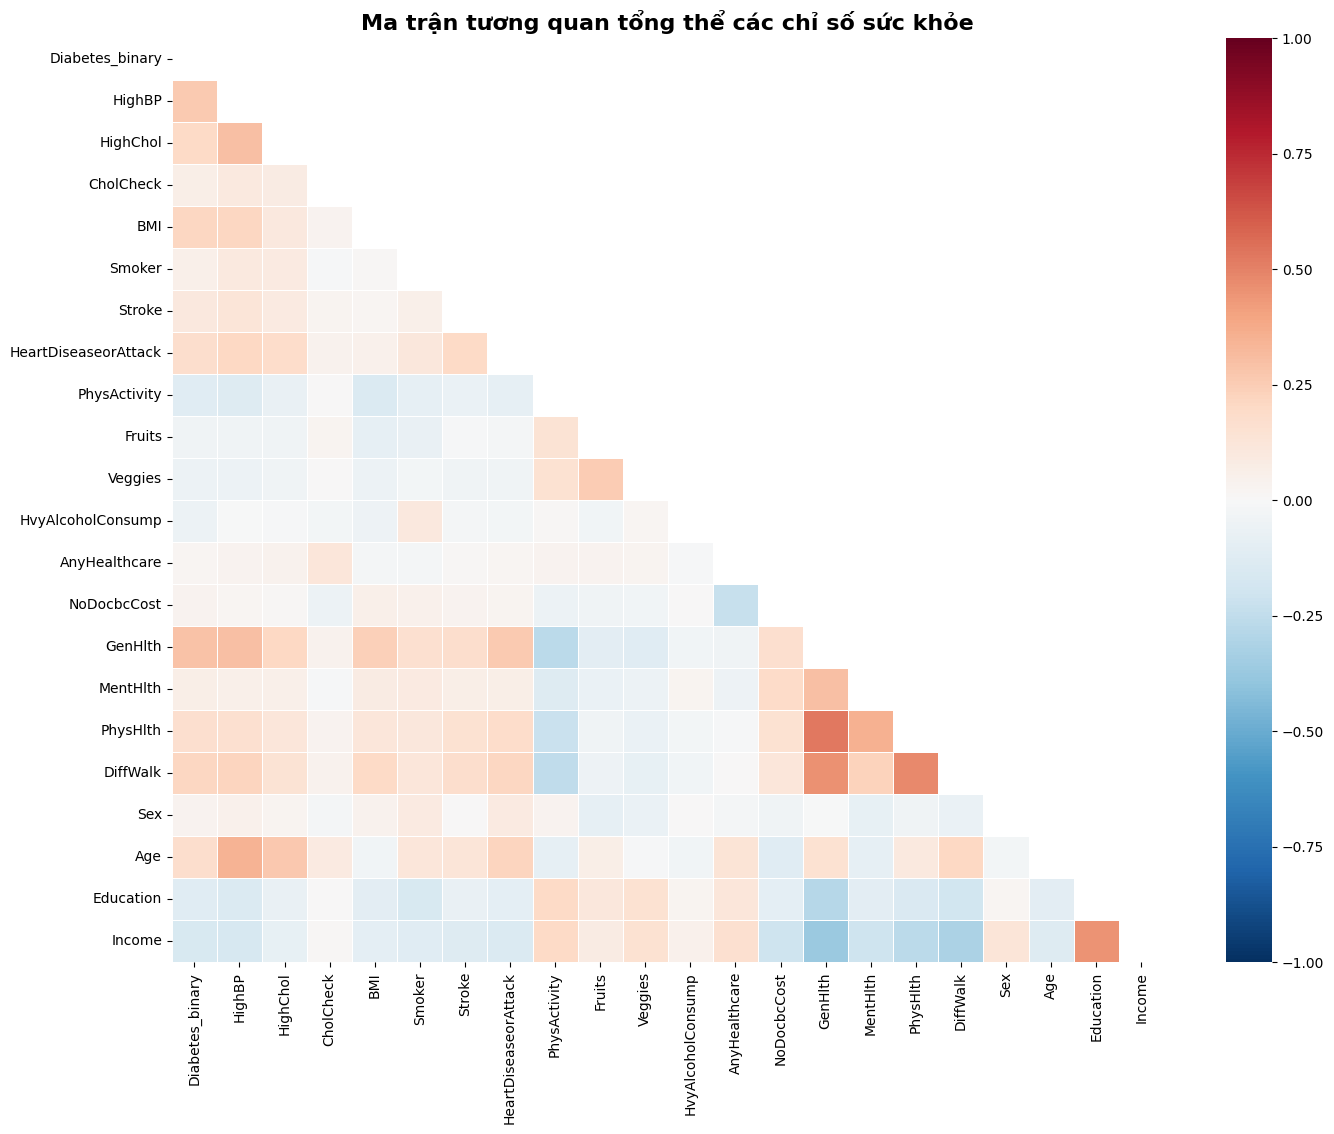

In [8]:
plt.figure(figsize=(16, 12))

# Tính toán ma trận tương quan Pearson
corr = df.corr()

# Tạo mask để che nửa trên của ma trận (vì nó đối xứng)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Vẽ Heatmap
sns.heatmap(corr, mask=mask, cmap='RdBu_r', annot=False, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Ma trận tương quan tổng thể các chỉ số sức khỏe', fontsize=16, fontweight='bold')
plt.show()

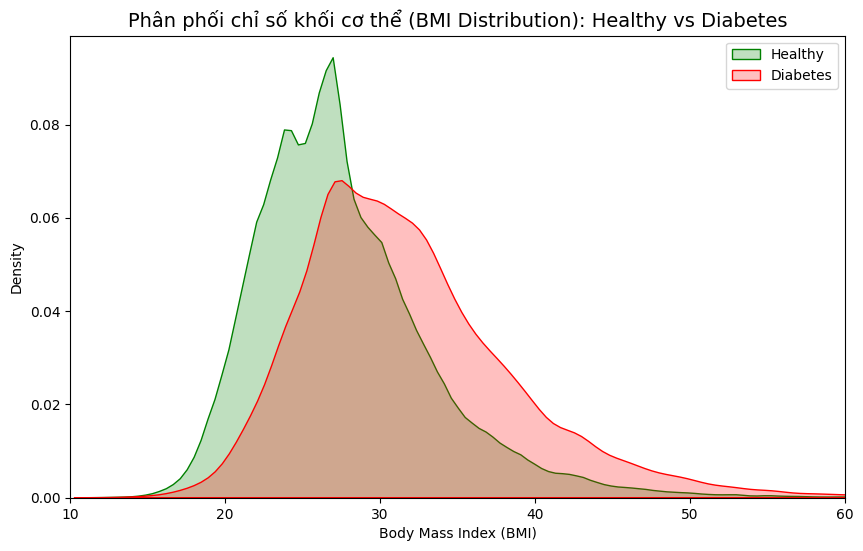

In [9]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df[df['Diabetes_binary']==0], x='BMI', fill=True, color='green', label='Healthy')
sns.kdeplot(data=df[df['Diabetes_binary']==1], x='BMI', fill=True, color='red', label='Diabetes')

plt.title('Phân phối chỉ số khối cơ thể (BMI Distribution): Healthy vs Diabetes', fontsize=14)
plt.xlim(10, 60) # Membatasi sumbu X agar outlier ekstrem tidak merusak tampilan
plt.xlabel('Body Mass Index (BMI)')
plt.legend()

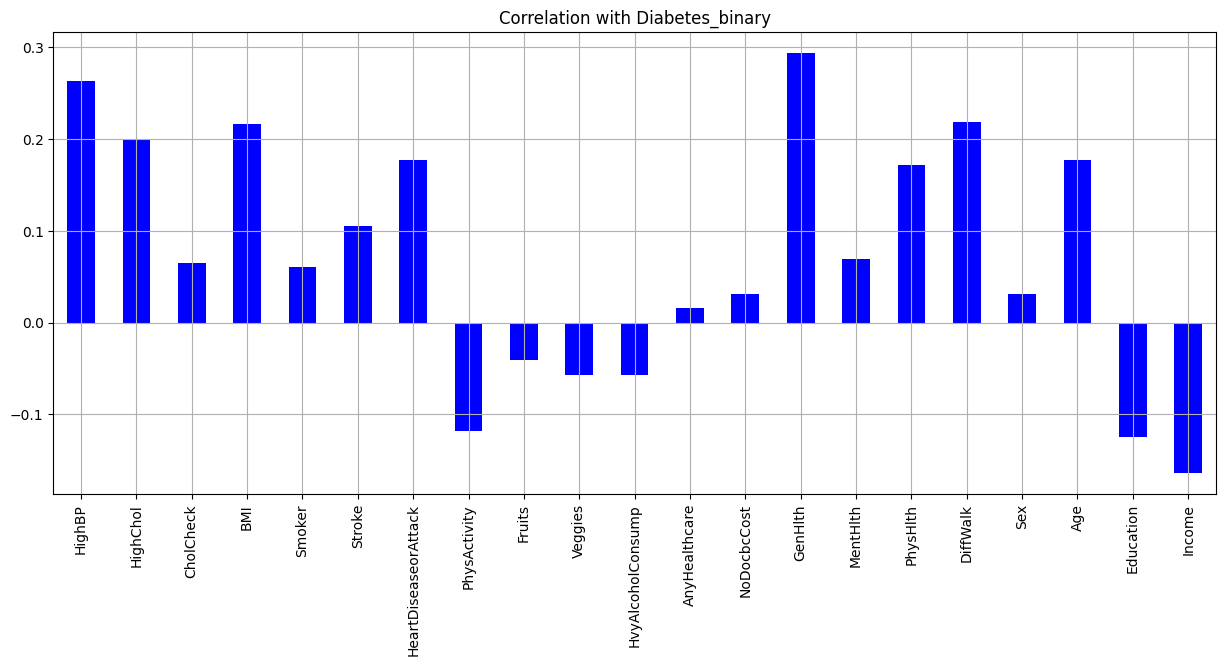

In [17]:
df.drop('Diabetes_binary', axis=1).corrwith(df.Diabetes_binary).plot(kind='bar', grid=True, figsize=(15, 6)
, title="biểu đồ Tương quan với bệnh Tiểu đường",color="blue");

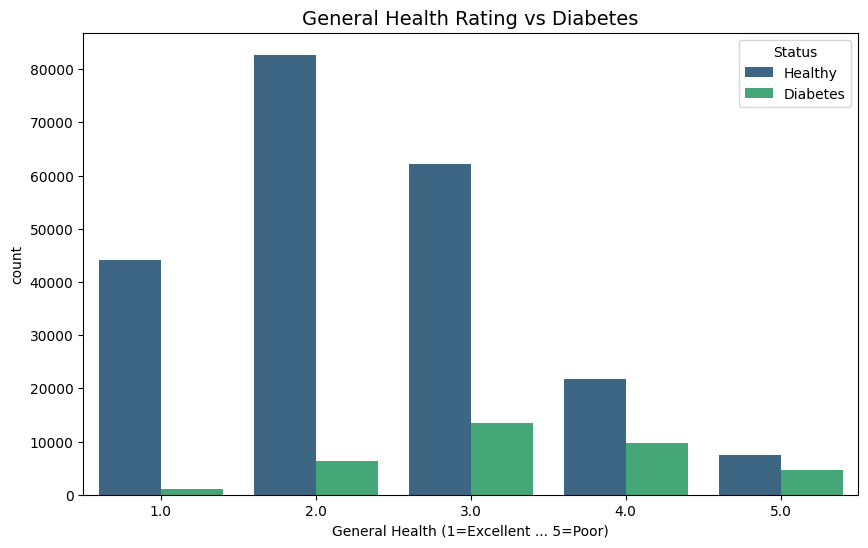

In [10]:
plt.figure(figsize=(10, 6))

sns.countplot(x='GenHlth', hue='Diabetes_binary', data=df, palette='viridis')
plt.title('General Health Rating vs Diabetes', fontsize=14)
plt.xlabel('General Health (1=Excellent ... 5=Poor)')
plt.legend(title='Status', labels=['Healthy', 'Diabetes'])

<Axes: >

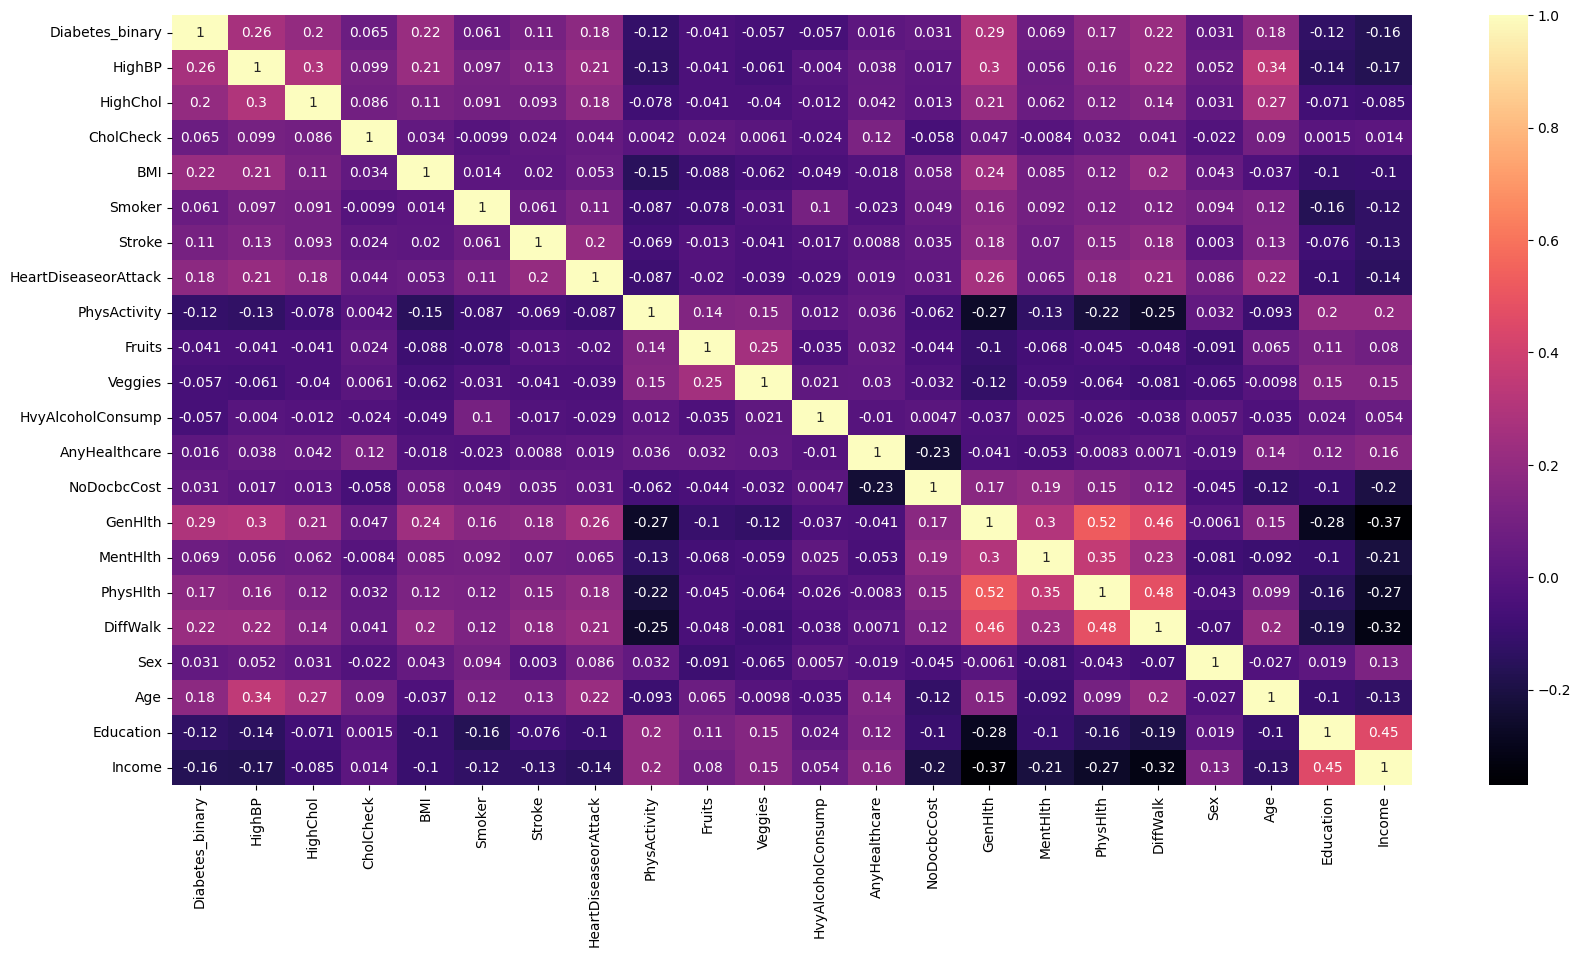

In [12]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True, cmap="magma")

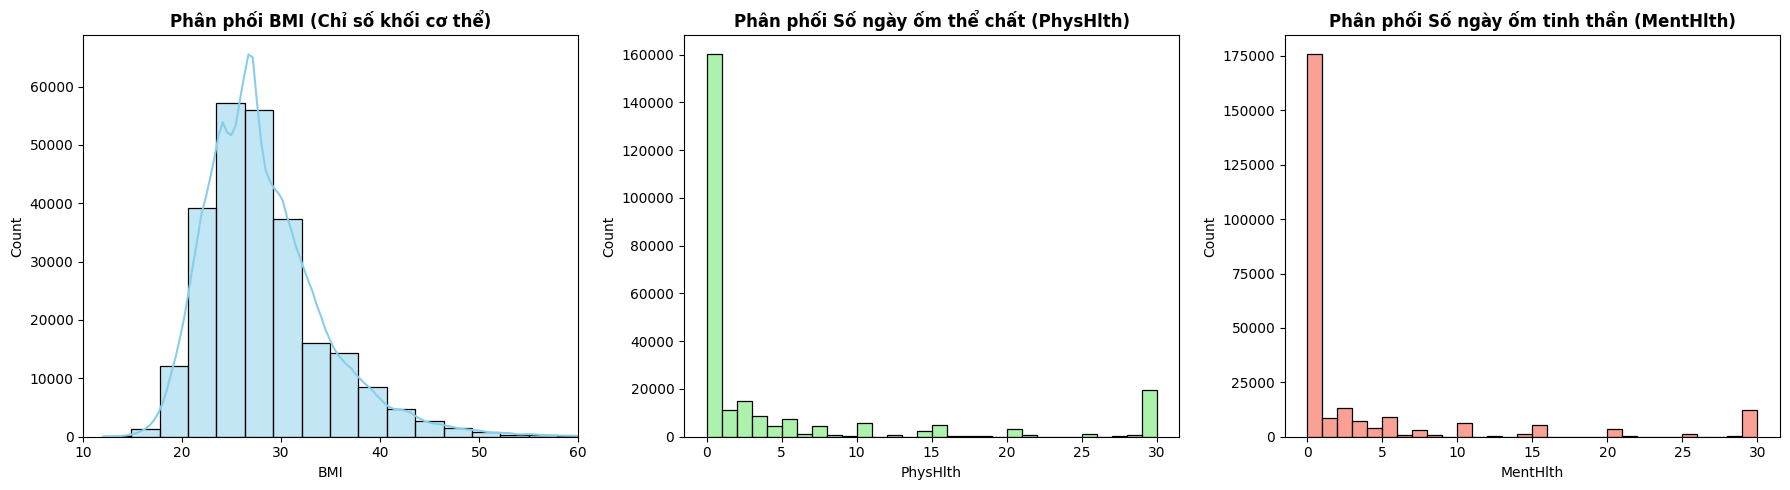

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['BMI'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Phân phối BMI (Chỉ số khối cơ thể)', fontweight='bold')
axes[0].set_xlim(10, 60)

sns.histplot(df['PhysHlth'], bins=30, color='lightgreen', ax=axes[1])
axes[1].set_title('Phân phối Số ngày ốm thể chất (PhysHlth)', fontweight='bold')

sns.histplot(df['MentHlth'], bins=30, color='salmon', ax=axes[2])
axes[2].set_title('Phân phối Số ngày ốm tinh thần (MentHlth)', fontweight='bold')

plt.tight_layout()
plt.show()

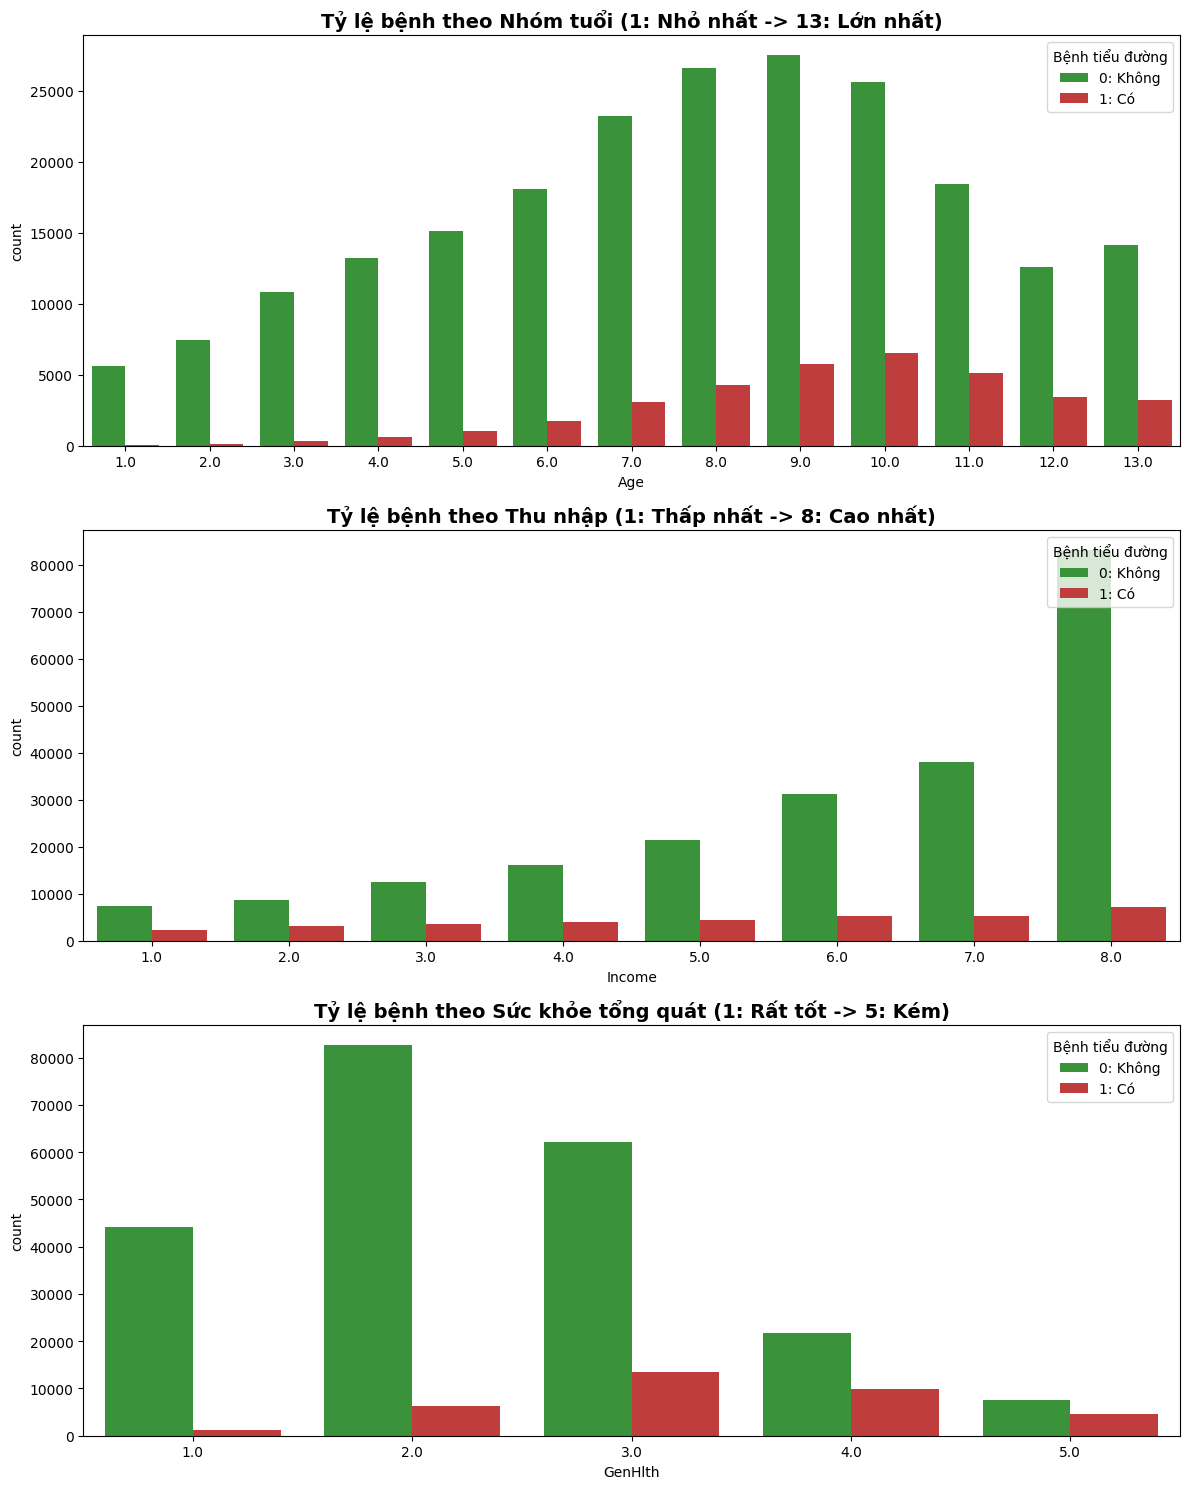

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Hàm phụ để vẽ biểu đồ countplot có nhãn (học từ ML EDA)
def plot_categorical(col, title, ax_idx):
    sns.countplot(data=df, x=col, hue='Diabetes_binary', ax=axes[ax_idx], palette=['#2ca02c', '#d62728'])
    axes[ax_idx].set_title(title, fontweight='bold', fontsize=14)
    axes[ax_idx].legend(title='Bệnh tiểu đường', labels=['0: Không', '1: Có'], loc='upper right')

# Vẽ 3 biểu đồ
plot_categorical('Age', 'Tỷ lệ bệnh theo Nhóm tuổi (1: Nhỏ nhất -> 13: Lớn nhất)', 0)
plot_categorical('Income', 'Tỷ lệ bệnh theo Thu nhập (1: Thấp nhất -> 8: Cao nhất)', 1)
plot_categorical('GenHlth', 'Tỷ lệ bệnh theo Sức khỏe tổng quát (1: Rất tốt -> 5: Kém)', 2)

plt.tight_layout()
plt.show()